In [1]:
%matplotlib ipympl
from tsut import NODE_REGISTRY

NodeRegistry with 0 registered nodes: []
Successfully registered nodes from module: tsut.components.nodes.data_sources._register
Successfully registered nodes from module: tsut.components.nodes.metrics._register
Successfully registered nodes from module: tsut.components.nodes.models._register
Successfully registered nodes from module: tsut.components.nodes.sinks._register
Successfully registered nodes from module: tsut.components.nodes.transforms.feature_selection._register
Successfully registered nodes from module: tsut.components.nodes.transforms.filters._register
Successfully registered nodes from module: tsut.components.nodes.transforms.imputations._register
Successfully registered nodes from module: tsut.components.nodes.transforms.operations._register


In [2]:
NODE_REGISTRY.list()

In [3]:
csv_config_class = NODE_REGISTRY["CSVFetcher"]['node_config_class']
csv_running_config_class = NODE_REGISTRY["CSVFetcher"]['extra_fields']['running_config_class']

In [4]:
default_csv_config = csv_config_class()
default_csv_config

CSVFetcherConfig(node_type=<NodeType.SOURCE: 'source'>, in_ports={}, out_ports={'data': Port(arr_type=<ArrayLikeEnum.PANDAS: 'pd.DataFrame'>, data_category=<DataCategoryEnum.MIXED: 'mixed_data'>, data_shape='batch features', desc='Fetched data from the CSV file.', mode=['all']), 'target': Port(arr_type=<ArrayLikeEnum.PANDAS: 'pd.DataFrame'>, data_category=<DataCategoryEnum.CATEGORICAL: 'categorical_data'>, data_shape='batch target_features', desc='Target values from the CSV file.', mode=['all'])}, mixins_config={}, running_config=CSVFetcherRunningConfig(data_file_path='data.csv', context_file_path='data_context.json', target_file_path='target.csv', target_context_file_path='target_context.json'))

In [5]:
default_csv_config.running_config.data_file_path = "../data/fake_batch.csv"
default_csv_config.running_config.context_file_path = "../data/fake_batch_context.json"
default_csv_config.running_config.target_file_path = "../data/fake_target_df.csv"
default_csv_config.running_config.target_context_file_path = "../data/fake_target_context.json"

In [6]:
from tsut.core.pipeline.pipeline import Pipeline, Edge, PipelineConfig

In [7]:
default_missing_filter_config = NODE_REGISTRY["MissingRateFilter"]['node_config_class']()
default_missing_filter_config.in_ports["input"].mode=["training", "evaluation"]
default_missing_filter_config.hyperparameters.threshold = 0.0

In [8]:
nodes ={
        "CSV Source": ("CSVFetcher", default_csv_config),
        "Remove Categorical": ("RemoveCategorical", None),
        "Missing Rate Filter": ("MissingRateFilter", None),
        "Target Missing Rate Filter": ("MissingRateFilter", default_missing_filter_config),
        "Random Forest Regressor": ("RandomForestRegressor", None),
        "Sink": ("Sink", None),
        "MSE Metric": ("MSEMetric", None)
}

In [9]:
edges = [
    Edge(source="CSV Source", target="Remove Categorical", ports_map={"input": "data"}),
    Edge(source="Remove Categorical", target="Missing Rate Filter", ports_map={"input": "output"}),
    Edge(source="Missing Rate Filter", target="Random Forest Regressor", ports_map={"X": "output"}),
    Edge(source="CSV Source", target="Target Missing Rate Filter", ports_map={"input": "target"}),
    Edge(source="Target Missing Rate Filter", target="Random Forest Regressor", ports_map={"y": "output"}),
    Edge(source="Random Forest Regressor", target="Sink", ports_map={"dump": "pred"}),
    Edge(source="Random Forest Regressor", target="MSE Metric", ports_map={"preds": "pred"}),
    Edge(source="Target Missing Rate Filter", target="MSE Metric", ports_map={"target": "output"})
]

In [10]:
nodes

{'CSV Source': ('CSVFetcher',
  CSVFetcherConfig(node_type=<NodeType.SOURCE: 'source'>, in_ports={}, out_ports={'data': Port(arr_type=<ArrayLikeEnum.PANDAS: 'pd.DataFrame'>, data_category=<DataCategoryEnum.MIXED: 'mixed_data'>, data_shape='batch features', desc='Fetched data from the CSV file.', mode=['all']), 'target': Port(arr_type=<ArrayLikeEnum.PANDAS: 'pd.DataFrame'>, data_category=<DataCategoryEnum.CATEGORICAL: 'categorical_data'>, data_shape='batch target_features', desc='Target values from the CSV file.', mode=['all'])}, mixins_config={}, running_config=CSVFetcherRunningConfig(data_file_path='../data/fake_batch.csv', context_file_path='../data/fake_batch_context.json', target_file_path='../data/fake_target_df.csv', target_context_file_path='../data/fake_target_context.json'))),
 'Remove Categorical': ('RemoveCategorical', None),
 'Missing Rate Filter': ('MissingRateFilter', None),
 'Target Missing Rate Filter': ('MissingRateFilter',
  MissingRateFilterConfig(node_type=<NodeType

In [11]:
pipe_conf = PipelineConfig(
    nodes=nodes,
    edges=edges,
)

pipe = Pipeline(config=pipe_conf)

In [12]:
from tsut.core.pipeline.runners.smart_runner import TabularSmartRunner

In [13]:
g = pipe.graph
g.degree()

DiDegreeView({'CSV Source': 2, 'Remove Categorical': 2, 'Missing Rate Filter': 2, 'Target Missing Rate Filter': 3, 'Random Forest Regressor': 4, 'Sink': 1, 'MSE Metric': 2})

In [14]:
for node in g.predecessors("Random Forest Regressor"):
    print(node)

Missing Rate Filter
Target Missing Rate Filter


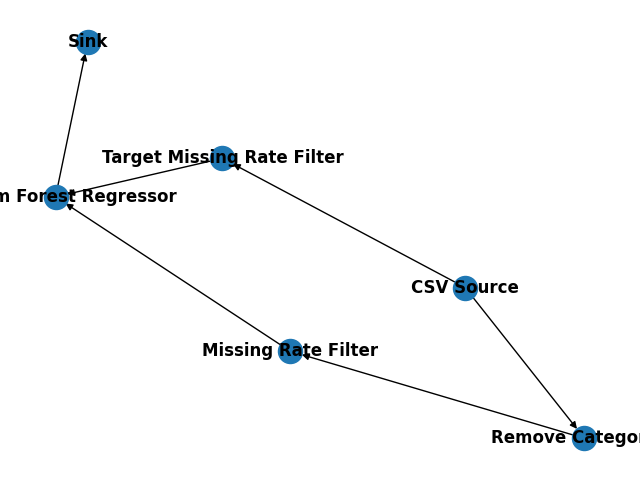

In [15]:
import networkx as nx
nx.draw(pipe.graph_wo_metrics, with_labels=True, font_weight='bold')

In [16]:
nx.shortest_path_length(pipe.graph, target="Sink")

{'Sink': 0,
 'Random Forest Regressor': 1,
 'Missing Rate Filter': 2,
 'Target Missing Rate Filter': 2,
 'Remove Categorical': 3,
 'CSV Source': 3}

In [ ]:
pipe.render()
pipe.compile()
runnable = TabularSmartRunner(pipe)

KeyError: 'data'

In [ ]:
runnable.train()

In [ ]:
runnable.infer()

{'Random Forest Regressor:pred': <tsut.core.common.data.tabular_data.TabularData at 0x125bbb570>}

In [ ]:
runnable.pipeline.get_params()

{'CSV Source': {},
 'Remove Categorical': {'features_to_remove': ['output_batch_id',
   'top1_element',
   'top2_element']},
 'Missing Rate Filter': {'columns_to_filter': ['mean_CHG_FS_AS_V',
   'mean_CHG_%O_V',
   'mean_CHG_RESTRICT-USE',
   'mean_CHG_FE%',
   'mean_CHG_FE_RATE',
   'total_pct_Par']},
 'Target Missing Rate Filter': {'columns_to_filter': ['PAIRED',
   'LOSS-VAC',
   'DPRES_LU',
   '4PS (G)',
   'DSINTER',
   'A2 15-20',
   'A2 20-75',
   'A275-125',
   'A2 >125',
   'MICRPO-A',
   'MICRPO-B',
   'MICRPO-C',
   'HM25-75',
   'HM75-125',
   'HM>125',
   'SM25-75',
   'SM75-125',
   'SM>125',
   'CONTB 25',
   'CONTB 75',
   'CONTB125',
   'CONTB175',
   'AGB15-20',
   'AGB20-75',
   'AGB75-12',
   'AGB >125',
   'SUM15-20',
   'SUM20-75',
   'BATCH_NB',
   'T°C_SINT',
   'OVEN_BAT',
   'TRS',
   '%CTOT_LU',
   'CO%',
   'CR2N%',
   'TIC%',
   'TANBC60%',
   'MO2C%',
   'NI%',
   'WC%',
   'VC%',
   'CONTR 25',
   'CONTR 75',
   'CONTR125',
   'LOSS-H2',
   'FS_AS_V',
   

In [ ]:
eval = runnable.evaluate()

In [ ]:
eval["MSE Metric"]["mse"]

column,output_batch_id_mse,FLOW-FAC_mse,DBULK_mse,PRESSURE_mse,SHRINKAG_mse,HV10_mse,4PS (S)_mse,HC_mse
dtype,float32,float32,float32,float32,float32,float32,float32,float32
category,numerical_data,numerical_data,numerical_data,numerical_data,numerical_data,numerical_data,numerical_data,numerical_data
0,397397.65625,0.27474,0.000609,1721.909912,0.0,25.031855,2.028921,7.586808
